# Classification d'Images CIFAR-10 avec un CNN (PyTorch)

CNN léger (3-5 couches de convolution) sur 10% de CIFAR-10 (32×32).
Pipeline complet : train / val / test + data augmentation + Optuna.


In [1]:
import os
import sys
import time
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as T
import optuna


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 6), "axes.titlesize": 14, "axes.labelsize": 12})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Noms des classes CIFAR-10
CIFAR10_CLASSES = [
    "avion", "automobile", "oiseau", "chat", "cerf",
    "chien", "grenouille", "cheval", "navire", "camion",
]

Device: cpu


## 1. Chargement et sous-échantillonnage de CIFAR-10 (10%)


In [2]:
DATA_DIR = os.path.join(".", "data")

# Transforms SANS augmentation (pour val/test)
transform_base = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

# Transforms AVEC augmentation (pour train)
transform_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, scale=(0.85, 1.15)),  # zoom
    T.RandomCrop(32, padding=4),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

# Chargement du dataset local
full_train = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=False, transform=transform_base)
full_test  = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=False, transform=transform_base)

print(f"CIFAR-10 complet : {len(full_train)} train, {len(full_test)} test")
print(f"Taille des images : {full_train[0][0].shape}")

CIFAR-10 complet : 50000 train, 10000 test
Taille des images : torch.Size([3, 32, 32])


In [3]:
def stratified_subset(dataset, fraction, seed=42):
    """Retourne les indices d'un sous-ensemble stratifié."""
    targets = np.array(dataset.targets)
    rng = np.random.RandomState(seed)
    indices = []
    for cls in range(10):
        cls_idx = np.where(targets == cls)[0]
        n_select = max(1, int(len(cls_idx) * fraction))
        chosen = rng.choice(cls_idx, size=n_select, replace=False)
        indices.extend(chosen.tolist())
    rng.shuffle(indices)
    return indices

# 10% du dataset complet
subset_indices = stratified_subset(full_train, fraction=0.10)
print(f"\nSous-ensemble : {len(subset_indices)} images (10% de {len(full_train)})")

# Vérification de la distribution
subset_targets = np.array(full_train.targets)[subset_indices]
unique, counts = np.unique(subset_targets, return_counts=True)
print("Distribution par classe :")
for cls, cnt in zip(unique, counts):
    print(f"  {CIFAR10_CLASSES[cls]:15s}: {cnt}")


Sous-ensemble : 5000 images (10% de 50000)
Distribution par classe :
  avion          : 500
  automobile     : 500
  oiseau         : 500
  chat           : 500
  cerf           : 500
  chien          : 500
  grenouille     : 500
  cheval         : 500
  navire         : 500
  camion         : 500


In [4]:
# On split le sous-ensemble 10% en : 70% train, 15% val, 15% test
from sklearn.model_selection import train_test_split

train_idx, temp_idx = train_test_split(
    subset_indices, test_size=0.30, random_state=SEED,
    stratify=np.array(full_train.targets)[subset_indices]
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED,
    stratify=np.array(full_train.targets)[temp_idx]
)

print(f"\nSplit final :")
print(f"  Train : {len(train_idx)}")
print(f"  Val   : {len(val_idx)}")
print(f"  Test  : {len(test_idx)}")

# Dataset augmenté pour le train
train_aug = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=False, transform=transform_aug)

train_set = Subset(train_aug, train_idx)
val_set   = Subset(full_train, val_idx)
test_set  = Subset(full_train, test_idx)


Split final :
  Train : 3500
  Val   : 750
  Test  : 750


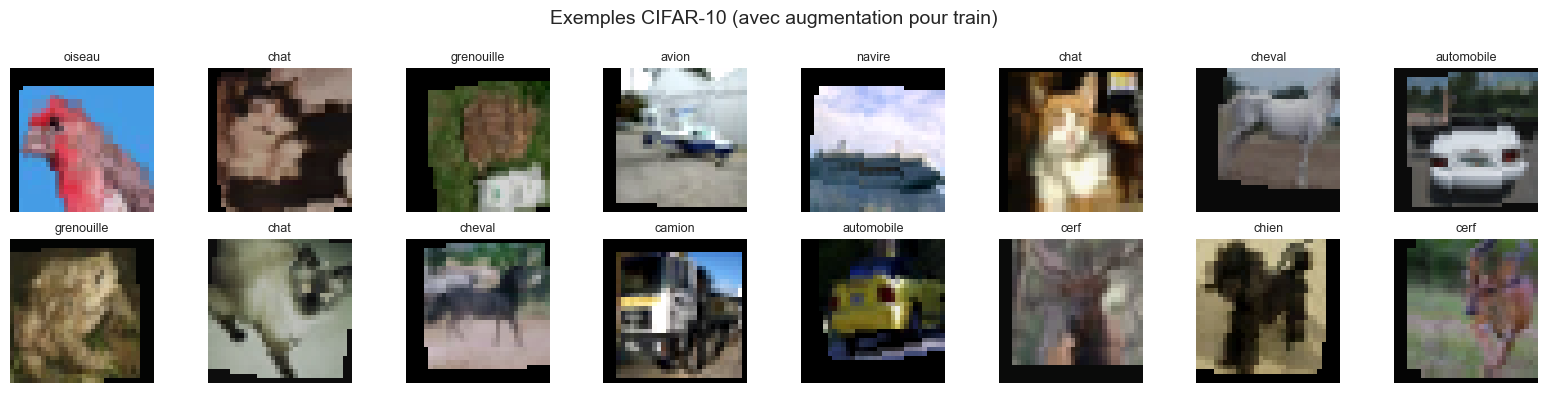

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle("Exemples CIFAR-10 (avec augmentation pour train)", fontsize=14)

for i, ax in enumerate(axes.flat):
    img, label = train_set[i]
    # Dénormaliser pour affichage
    img_np = img.numpy().transpose(1, 2, 0)
    mean = np.array([0.4914, 0.4822, 0.4465])
    std  = np.array([0.2470, 0.2435, 0.2616])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)
    ax.imshow(img_np)
    ax.set_title(CIFAR10_CLASSES[label], fontsize=9)
    ax.axis("off")

plt.tight_layout()

plt.show()

## 2. Architecture CNN


In [6]:
class CIFAR10CNN(nn.Module):
    """
    CNN léger avec 3 à 5 blocs Conv-BN-ReLU-Pool.
    Architecture paramétrable pour Optuna.
    """
    def __init__(self, n_conv_layers=4, base_filters=32, dropout_rate=0.3,
                 use_batchnorm=True, fc_size=256):
        super().__init__()

        layers = []
        in_channels = 3
        current_size = 32  # taille spatiale courante

        for i in range(n_conv_layers):
            out_channels = base_filters * (2 ** min(i, 3))  # cap à 8x
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU(inplace=True))
            # Pool seulement si la taille spatiale > 2
            if current_size > 2:
                layers.append(nn.MaxPool2d(2, 2))
                current_size //= 2
            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        # Calculer la taille du flatten
        self._flat_size = in_channels * current_size * current_size

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(self._flat_size, fc_size),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(fc_size, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Test rapide de l'architecture
model_test = CIFAR10CNN(n_conv_layers=4, base_filters=32)
dummy = torch.randn(2, 3, 32, 32)
out = model_test(dummy)
print(f"Architecture test — entrée: {dummy.shape} → sortie: {out.shape}")
total_params = sum(p.numel() for p in model_test.parameters())
print(f"Nombre de paramètres : {total_params:,}")
del model_test

Architecture test — entrée: torch.Size([2, 3, 32, 32]) → sortie: torch.Size([2, 10])
Nombre de paramètres : 654,346


## 3. Entraînement avec Optuna


In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

In [8]:
N_EPOCHS_OPTUNA = 10
PATIENCE = 5

def objective(trial):
    # Hyperparamètres à optimiser
    n_conv_layers = trial.suggest_int("n_conv_layers", 3, 5)
    base_filters = trial.suggest_categorical("base_filters", [16, 32, 64])
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.05)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    fc_size = trial.suggest_categorical("fc_size", [128, 256, 512])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

    # DataLoaders
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=128, shuffle=False,
                            num_workers=0, pin_memory=True)

    # Modèle
    model = CIFAR10CNN(
        n_conv_layers=n_conv_layers,
        base_filters=base_filters,
        dropout_rate=dropout_rate,
        use_batchnorm=use_batchnorm,
        fc_size=fc_size,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(N_EPOCHS_OPTUNA):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        # Pruning Optuna
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    return best_val_acc

In [ ]:
print("=" * 60)
print("Lancement de l'optimisation Optuna (15 trials)")
print("=" * 60)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",
    study_name="CNN_CIFAR10_10pct",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5),
)

study.optimize(objective, n_trials=10, show_progress_bar=True)

print(f"\nMeilleur trial :")
print(f"  Val Accuracy : {study.best_value:.4f}")
print(f"  Paramètres   : {study.best_params}")

Lancement de l'optimisation Optuna (15 trials)


  0%|          | 0/10 [00:00<?, ?it/s]

C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 4. Entraînement final avec les meilleurs hyperparamètres


In [ ]:
N_EPOCHS_FINAL = 40
best = study.best_params

print("\n" + "=" * 60)
print("Entraînement final avec les meilleurs hyperparamètres")
print("=" * 60)

# DataLoaders
train_loader = DataLoader(train_set, batch_size=best["batch_size"], shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=0)

# Modèle final
final_model = CIFAR10CNN(
    n_conv_layers=best["n_conv_layers"],
    base_filters=best["base_filters"],
    dropout_rate=best["dropout_rate"],
    use_batchnorm=best["use_batchnorm"],
    fc_size=best["fc_size"],
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best["lr"],
                             weight_decay=best["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
best_state = None

t_start = time.time()
for epoch in range(N_EPOCHS_FINAL):
    train_loss, train_acc = train_one_epoch(final_model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(final_model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in final_model.state_dict().items()}

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS_FINAL} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

elapsed = time.time() - t_start
print(f"\nEntraînement terminé en {elapsed:.1f}s")
print(f"Meilleure Val Accuracy : {best_val_acc:.4f}")

# Charger le meilleur modèle
final_model.load_state_dict(best_state)


Entraînement final avec les meilleurs hyperparamètres
Epoch   1/40 | Train Loss: 2.0614 Acc: 0.2357 | Val Loss: 1.8538 Acc: 0.2973
Epoch   5/40 | Train Loss: 1.5302 Acc: 0.4294 | Val Loss: 1.5313 Acc: 0.4560
Epoch  10/40 | Train Loss: 1.3227 Acc: 0.5214 | Val Loss: 1.2755 Acc: 0.5533
Epoch  15/40 | Train Loss: 1.1355 Acc: 0.5929 | Val Loss: 1.1878 Acc: 0.5853


RuntimeError: could not execute a primitive

## 5. Évaluation finale sur le jeu de test


In [ ]:
test_loss, test_acc, test_preds, test_labels = evaluate(
    final_model, test_loader, criterion, device
)

print(f"\n{'='*60}")
print(f"RÉSULTATS SUR LE JEU DE TEST")
print(f"{'='*60}")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"\nRapport de classification :")
print(classification_report(test_labels, test_preds, target_names=CIFAR10_CLASSES))


RÉSULTATS SUR LE JEU DE TEST
Test Loss     : 0.9314
Test Accuracy : 0.6440

Rapport de classification :
              precision    recall  f1-score   support

       avion       0.65      0.77      0.71        75
  automobile       0.66      0.92      0.77        75
      oiseau       0.54      0.52      0.53        75
        chat       0.42      0.28      0.34        75
        cerf       0.67      0.44      0.53        75
       chien       0.49      0.63      0.55        75
  grenouille       0.80      0.71      0.75        75
      cheval       0.65      0.71      0.68        75
      navire       0.85      0.83      0.84        75
      camion       0.70      0.64      0.67        75

    accuracy                           0.64       750
   macro avg       0.64      0.64      0.64       750
weighted avg       0.64      0.64      0.64       750



## 6. Visualisations


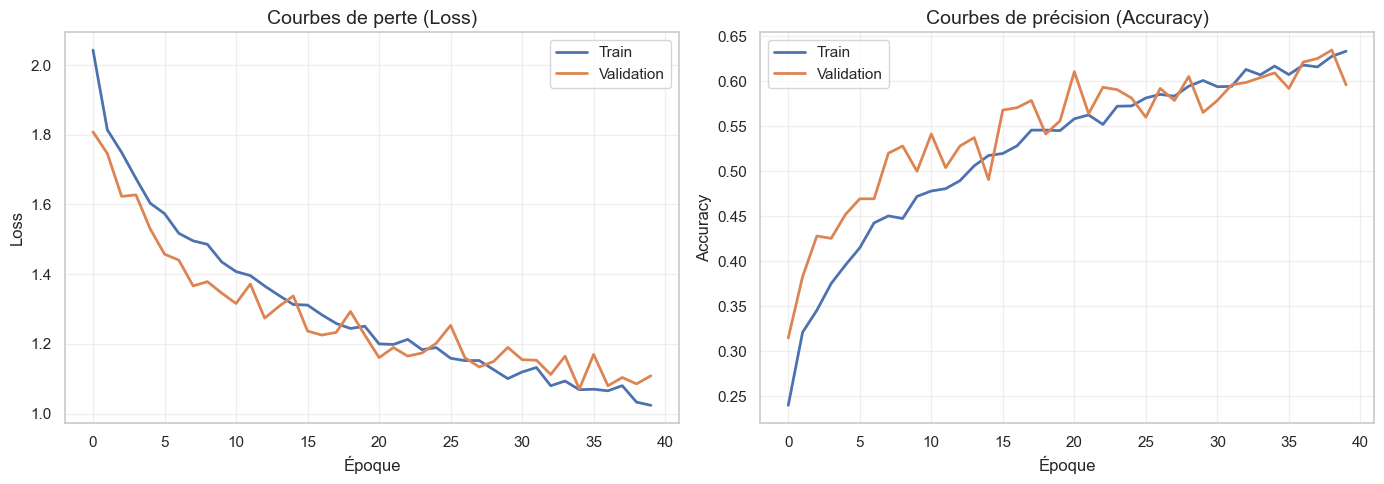

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train", linewidth=2)
ax1.plot(history["val_loss"], label="Validation", linewidth=2)
ax1.set_xlabel("Époque")
ax1.set_ylabel("Loss")
ax1.set_title("Courbes de perte (Loss)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["train_acc"], label="Train", linewidth=2)
ax2.plot(history["val_acc"], label="Validation", linewidth=2)
ax2.set_xlabel("Époque")
ax2.set_ylabel("Accuracy")
ax2.set_title("Courbes de précision (Accuracy)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(".", "learning_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

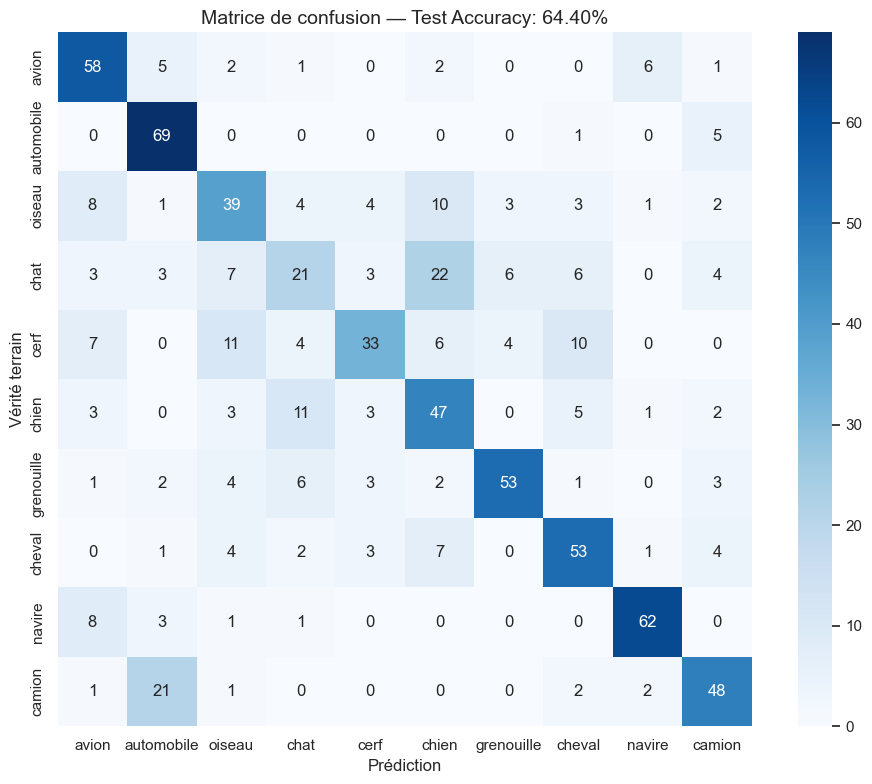

In [ ]:
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES, ax=ax, square=True)
ax.set_xlabel("Prédiction")
ax.set_ylabel("Vérité terrain")
ax.set_title(f"Matrice de confusion — Test Accuracy: {test_acc:.2%}")
plt.tight_layout()
plt.savefig(os.path.join(".", "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

C:\Users\afagn\AppData\Local\Temp\ipykernel_6864\3337562222.py:37: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\afagn\AppData\Local\Temp\ipykernel_6864\3337562222.py:37: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\afagn\AppData\Local\Temp\ipykernel_6864\3337562222.py:38: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(os.path.join(".", "predictions.png"), dpi=150, bbox_inches="tight")
C:\Users\afagn\AppData\Local\Temp\ipykernel_6864\3337562222.py:38: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig(os.path.join(".", "predictions.png"), dpi=150, bbox_inches="tight")
C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.can

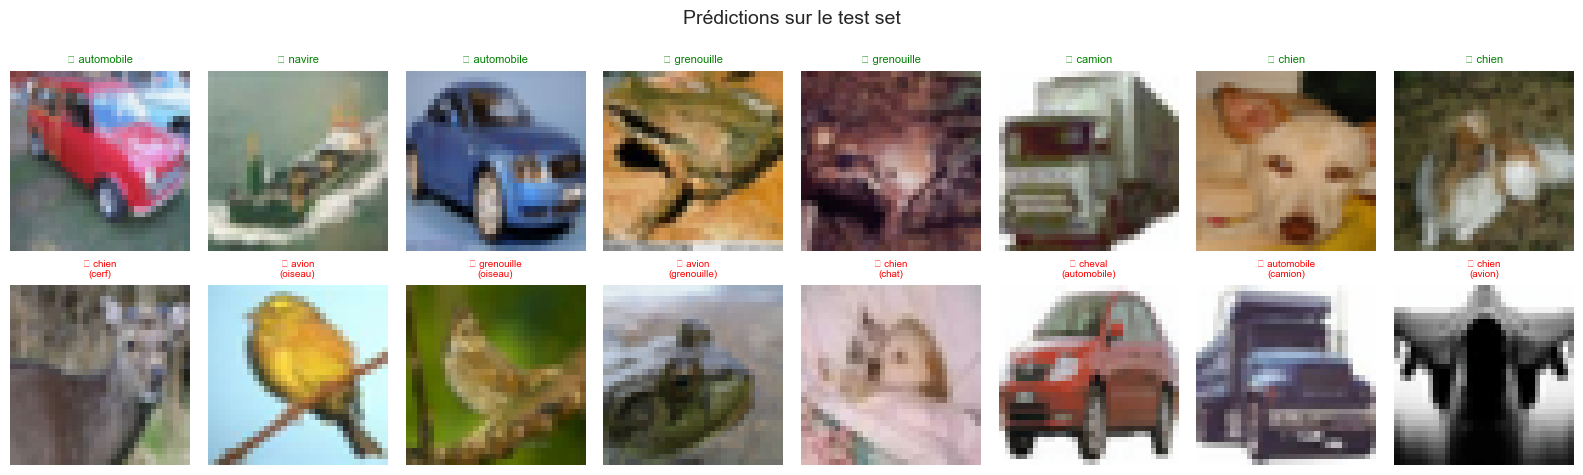

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Prédictions sur le test set", fontsize=14)

mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2470, 0.2435, 0.2616])

# 8 correct + 8 incorrect
correct_mask = test_preds == test_labels
wrong_mask   = ~correct_mask

correct_idx = np.where(correct_mask)[0][:8]
wrong_idx   = np.where(wrong_mask)[0][:8]

for i, idx in enumerate(correct_idx):
    img, _ = test_set[idx]
    img_np = img.numpy().transpose(1, 2, 0) * std + mean
    img_np = np.clip(img_np, 0, 1)
    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"✓ {CIFAR10_CLASSES[test_preds[idx]]}", fontsize=8, color="green")
    axes[0, i].axis("off")

for i, idx in enumerate(wrong_idx):
    if i >= 8:
        break
    img, _ = test_set[idx]
    img_np = img.numpy().transpose(1, 2, 0) * std + mean
    img_np = np.clip(img_np, 0, 1)
    axes[1, i].imshow(img_np)
    true_cls = CIFAR10_CLASSES[test_labels[idx]]
    pred_cls = CIFAR10_CLASSES[test_preds[idx]]
    axes[1, i].set_title(f"✗ {pred_cls}\n({true_cls})", fontsize=7, color="red")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Corrects", fontsize=11, rotation=0, labelpad=50)
axes[1, 0].set_ylabel("Erreurs", fontsize=11, rotation=0, labelpad=50)

plt.tight_layout()
plt.savefig(os.path.join(".", "predictions.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("\n" + "=" * 60)
print("RÉSUMÉ")
print("=" * 60)
print(f"Dataset        : CIFAR-10 (10% = {len(subset_indices)} images)")
print(f"Split          : Train {len(train_idx)} / Val {len(val_idx)} / Test {len(test_idx)}")
print(f"Architecture   : CNN {best['n_conv_layers']} couches conv, "
      f"base_filters={best['base_filters']}, fc={best['fc_size']}")
print(f"Augmentation   : Flip, Rotation(±15°), Zoom(0.85-1.15), Crop, ColorJitter")
print(f"Optuna trials  : {len(study.trials)}")
print(f"Best Val Acc   : {best_val_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test F1 (macro): {f1_score(test_labels, test_preds, average='macro'):.4f}")


RÉSUMÉ
Dataset        : CIFAR-10 (10% = 5000 images)
Split          : Train 3500 / Val 750 / Test 750
Architecture   : CNN 4 couches conv, base_filters=16, fc=128
Augmentation   : Flip, Rotation(±15°), Zoom(0.85-1.15), Crop, ColorJitter
Optuna trials  : 10
Best Val Acc   : 0.6347
Test Accuracy  : 0.6440
Test F1 (macro): 0.6358
